# Clean data

In [72]:
import pandas as pd
import numpy as np

In [73]:
df = pd.read_csv('C:/Users/DELL/OneDrive/Tài liệu/weather_raw_2013_2025.csv')
print(f"Tổng số dòng của dữ liệu : {df.shape[0]}")

Tổng số dòng của dữ liệu : 181960


In [74]:
print(df.head())

   province   max   min wind wind_d  rain  humidi  cloud  pressure        date
0  Bac Lieu  27.0  22.0   17    NNE   6.9    90.0   71.0    1010.0  2013-01-01
1  Bac Lieu  31.0  25.0   20    ENE   0.0    64.0   24.0    1010.0  2014-01-01
2  Bac Lieu  29.0  24.0   14      E   0.0    75.0   45.0    1008.0  2015-01-01
3  Bac Lieu  30.0  24.0   30      E   0.0    79.0   52.0    1012.0  2016-01-01
4  Bac Lieu  31.0  25.0   20    ENE   0.0     NaN   24.0       NaN  2017-01-01


Xem kiểu dữ liệu của từng cột 

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181960 entries, 0 to 181959
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   province  181960 non-null  object 
 1   max       178330 non-null  float64
 2   min       178321 non-null  float64
 3   wind      181960 non-null  object 
 4   wind_d    181960 non-null  object 
 5   rain      178321 non-null  float64
 6   humidi    178321 non-null  float64
 7   cloud     178321 non-null  float64
 8   pressure  178321 non-null  float64
 9   date      181960 non-null  object 
dtypes: float64(6), object(4)
memory usage: 13.9+ MB


* Cột data đang là kiểu dữ liệu 'object' chuyển sang kiểu datatime có trong pd
* Cột wind đang là kiểu dữ liệu "object" cần chuyển sang kiểu số numeric. Vì đơn vị của tốc độ gió là số (tốc độ gió km/h)

In [76]:
df['date'] = pd.to_datetime(df['date'])

# Tham số errors='coerce': Nó sẽ giữ lại các con số, còn ký tự chữ nào không thể chuyển thành số sẽ tự động bị biến thành NaN.
df['wind'] = pd.to_numeric(df['wind'], errors='coerce')

# kiểm tra kiểu dữ liệu
df[['date','wind']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181960 entries, 0 to 181959
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    181960 non-null  datetime64[ns]
 1   wind    181051 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.8 MB


Biểu đồ trực quan giá trị NaN cho từng cột

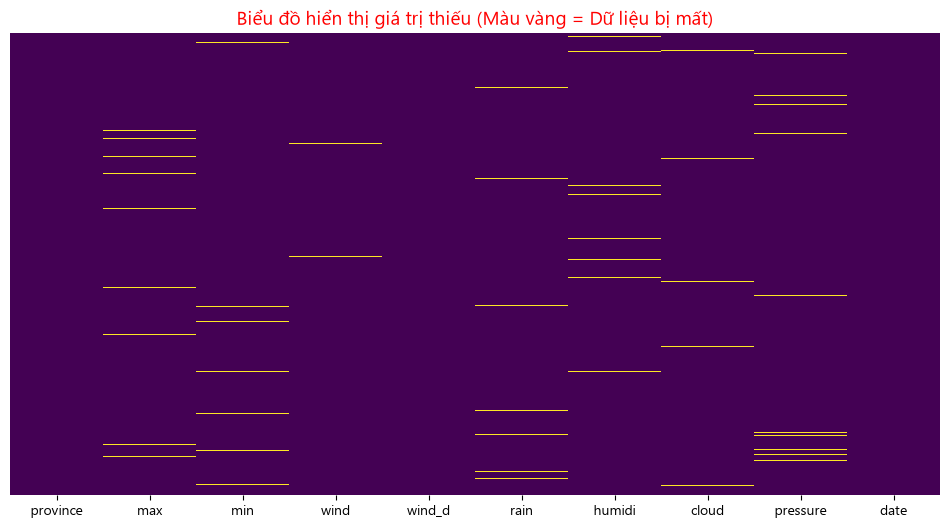

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước biểu đồ rộng ra để nhìn cho rõ 181.000 dòng
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ Heatmap. 
# yticklabels=False: Ẩn trục Y vì có quá nhiều dòng
# cbar=False: Ẩn thanh chú thích màu sắc cho gọn
# cmap='viridis': Dải màu làm cho NaN biến thành màu vàng rực
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title("Biểu đồ hiển thị giá trị thiếu (Màu vàng = Dữ liệu bị mất)", fontsize=14, color='red')
plt.show()

Tổng số ô có giá trị NaN của mỗi cột 

In [78]:
df.isnull().sum()

province       0
max         3630
min         3639
wind         909
wind_d         0
rain        3639
humidi      3639
cloud       3639
pressure    3639
date           0
dtype: int64

## Tách cột date ra thành các cột ngày, tháng, năm. Để thuận tiện cho việc gom nhóm

In [79]:
df['Day'] = df['date'].dt.day
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
print(df.head())

   province   max   min  wind wind_d  rain  humidi  cloud  pressure  \
0  Bac Lieu  27.0  22.0  17.0    NNE   6.9    90.0   71.0    1010.0   
1  Bac Lieu  31.0  25.0  20.0    ENE   0.0    64.0   24.0    1010.0   
2  Bac Lieu  29.0  24.0  14.0      E   0.0    75.0   45.0    1008.0   
3  Bac Lieu  30.0  24.0  30.0      E   0.0    79.0   52.0    1012.0   
4  Bac Lieu  31.0  25.0  20.0    ENE   0.0     NaN   24.0       NaN   

        date  Day  Month  Year  
0 2013-01-01    1      1  2013  
1 2014-01-01    1      1  2014  
2 2015-01-01    1      1  2015  
3 2016-01-01    1      1  2016  
4 2017-01-01    1      1  2017  


Gom tên tỉnh lại thành 1 không trùng lặp, những tháng tương ứng với tỉnh đó gộp thành 1 ( ví dụ: gộp tháng 2 tỉnh Bac lieu từ năm 2013 - 2025 => thì có 364 dòng)

In [80]:
# ví dụ 
bang_dai_dien = df.groupby(['province', 'Month']).size()
print(bang_dai_dien)

province  Month
Bac Lieu  1        403
          2        364
          3        403
          4        390
          5        403
                  ... 
Yen Bai   8        372
          9        360
          10       372
          11       360
          12       372
Length: 480, dtype: int64


Nhiệt độ thì tăng giảm đều đặn nên dùng Trung bình. Còn lượng mưa có tính chất "giàu nghèo" đột biến (quá nhiều số 0 và vài số quá to) nên bắt buộc phải dùng Trung vị để không bị các ngày bão làm sai lệch bức tranh thực tế.

In [81]:
# Xử lý cột 'rain' (Lượng mưa) bằng Trung vị của Tỉnh theo từng Tháng
# groupby(['province', 'Month']): gom cột province và Month thành 1 nhóm 
# sắp sếp lượng mưa theo thứ thị tăng dần theo năm rồi tính trung vị tháng đó năm đó và điền vào giá trị nan
df['rain'] = df.groupby(['province', 'Month'])['rain'].transform(lambda x: x.fillna(x.median()))
print("Số NaN còn lại của cột rain:", df['rain'].isnull().sum())

Số NaN còn lại của cột rain: 0


Khí tượng học có tính kế thừa. Nhiệt độ của ngày hôm nay thường không chênh lệch quá nhiều so với ngày hôm qua. Do đó, nếu ngày 15 bị thiếu, ta có thể mượn nhiệt độ của ngày 14 (ffill) hoặc ngày 16 (bfill) để điền vào.

In [82]:
# Xử lý cột 'max' và 'min' bằng phương pháp lấp đầy lân cận
cols_temp = ['max', 'min']

for col in cols_temp:
    # ffill: lấy ngày đầu đắp cho ngày sau. bfill: lấy ngày sau đắp cho đầu trước
    df[col] = df.groupby('province')[col].transform(lambda x: x.ffill().bfill())

print("Số NaN còn lại của max, min:\n", df[cols_temp].isnull().sum())

Số NaN còn lại của max, min:
 max    0
min    0
dtype: int64


Nếu ngày mùng 1 độ ẩm là 70%, ngày mùng 3 độ ẩm là 80%, thuật toán Nội suy sẽ tự động tính toán khoảng cách tăng liên tực và nội suy ngày mùng 2 ở giữa là 75%. Vì trong tự nhiên độ ẩm và áp suất không đột ngột nhảy bậc thang, mà nó sẽ tăng hoặc giảm từ từ.

In [83]:
# Xử lý cột 'humidi' (Độ ẩm) và 'pressure' (Áp suất) bằng Nội suy tuyến tính
cols_inter = ['humidi', 'pressure']

for col in cols_inter:
    df[col] = df.groupby('province')[col].transform(lambda x: x.interpolate(method='linear').ffill().bfill())

print("Số NaN còn lại của humidi, pressure:\n", df[cols_inter].isnull().sum())

Số NaN còn lại của humidi, pressure:
 humidi      0
pressure    0
dtype: int64


Cột mật độ mây (cloud) thường khó dự đoán tuyến tính. Nếu các phương pháp trên vẫn còn sót lại một vài ô NaN (do tỉnh đó mất dữ liệu quá dài), ta có thể điền bằng một hằng số an toàn (ví dụ: mật độ mây trung bình chung là 50), hoặc xóa bỏ những dòng cứng đầu cuối cùng.

In [84]:
# Xử lý cột 'cloud' bằng Trung bình chung, sau đó xóa những dòng thực sự không thể cứu
df['cloud'] = df.groupby('province')['cloud'].transform(lambda x: x.fillna(x.mean()))

# Nếu đến bước này mà bất kỳ cột nào vẫn còn NaN thì dùng lệnh xóa (Dropna)
df.dropna(inplace=True)

In [85]:
print("Kết quả kiểm tra cuối cùng")
print(df.isnull().sum())

Kết quả kiểm tra cuối cùng
province    0
max         0
min         0
wind        0
wind_d      0
rain        0
humidi      0
cloud       0
pressure    0
date        0
Day         0
Month       0
Year        0
dtype: int64


# Biến đổi Đặc trưng

Nhiệt độ Max và Min đứng riêng lẻ thì chưa nói lên được sự khắc nghiệt. Ta cần tính Biên độ nhiệt (Temp_Range). Biên độ nhiệt càng lớn chứng tỏ ngày đó thời tiết càng khắc nghiệt (sáng nắng gắt, đêm lạnh buốt).

In [86]:
# Tạo cột Biên độ nhiệt
df['Temp_Range'] = df['max'] - df['min']
print(df.columns.tolist())

['province', 'max', 'min', 'wind', 'wind_d', 'rain', 'humidi', 'cloud', 'pressure', 'date', 'Day', 'Month', 'Year', 'Temp_Range']


In [87]:
# kiểm tra xem nhiệt độ cao ở buổi trữa mà = nhiệt độ ở buổi tối ngày hôm đó. cần phải thực hiện tính trung bình tháng đó
print("Số ngày có max bằng min:", (df['Temp_Range'] == 0).sum())

Số ngày có max bằng min: 589


Thay vì xóa, chúng ta sẽ bắt Pandas sửa lại những ngày lỗi này bằng cách cho min (hoặc max) mượn tạm Biên độ nhiệt trung bình của tháng đó.

In [88]:
# Tính Biên độ nhiệt trung bình của từng tỉnh theo từng tháng (Bỏ qua những ngày lỗi Temp_Range = 0)
mean_temp_range = df[df['Temp_Range'] > 0].groupby(['province', 'Month'])['Temp_Range'].mean()
print(mean_temp_range)


province  Month
Bac Lieu  1         6.902500
          2         7.854396
          3        82.286783
          4         6.925258
          5         5.852868
                     ...    
Yen Bai   8        61.310811
          9         7.271186
          10        7.134409
          11        7.340782
          12        7.160326
Name: Temp_Range, Length: 480, dtype: float64


Xuất hiện biên độ nhiệt lên đến   82.286783 độ C, biên độ nhiệt đang bị sai

In [89]:
# Xem biên độ nhiệt hoang đường nhất ở Bạc Liêu tháng 3
loi_bac_lieu = df[(df['province'] == 'Bac Lieu') & (df['Month'] == 3)].sort_values('Temp_Range', ascending=False)
print("Các ngày lỗi ở Bạc Liêu:")
print(loi_bac_lieu[['date', 'max', 'min', 'Temp_Range']].head())

print("-" * 30)

# Xem có biên độ nhiệt hoang đường nhất ở Yên Bái tháng 8
loi_yen_bai = df[(df['province'] == 'Yen Bai') & (df['Month'] == 8)].sort_values('Temp_Range', ascending=False)
print("Các ngày lỗi ở Yên Bái:")
print(loi_yen_bai[['date', 'max', 'min', 'Temp_Range']].head())

Các ngày lỗi ở Bạc Liêu:
           date     max   min  Temp_Range
813  2020-03-07  9999.0  25.0      9974.0
895  2024-03-14  9999.0  25.0      9974.0
797  2017-03-02  9999.0  25.0      9974.0
1107 2015-03-31    36.0  25.0        11.0
869  2024-03-10    36.0  25.0        11.0
------------------------------
Các ngày lỗi ở Yên Bái:
             date     max   min  Temp_Range
161944 2017-08-04  9999.0  24.0      9975.0
161945 2018-08-04  9999.0  25.0      9974.0
162300 2013-08-26    36.0  22.0        14.0
162020 2021-08-12    37.0  24.0        13.0
162230 2015-08-29    35.0  23.0        12.0


cột giá trị max đang xuất hiện 9999.0 vì nhiệt độ cao nhất ở việt nam chỉ ở mức 44 độ C. Cần thực hiện clean cột max 

In [90]:
import numpy as np

# Xóa sổ các giá trị vô lý
# 1a. Nếu max >= 100 độ (ví dụ 9999), biến nó thành NaN
df.loc[df['max'] >= 100, 'max'] = np.nan

# Nếu min < -10 độ (Ở VN không thể lạnh quá -10 độ), biến nó thành NaN
df.loc[df['min'] < -10, 'min'] = np.nan

# Gán lại những chỗ vừa xóa (Dùng phương pháp nội suy ffill để lấy ngày hôm trước đắp xuống)
df['max'] = df.groupby('province')['max'].transform(lambda x: x.ffill().bfill())
df['min'] = df.groupby('province')['min'].transform(lambda x: x.ffill().bfill())

# Tính toán lại Temp_Range
df['Temp_Range'] = df['max'] - df['min']
df['Temp_Range'] = df['Temp_Range'].round(1)

# Tính lại Cuốn sổ tay (mean_temp_range) - Lúc này số liệu sẽ cực kỳ chuẩn!
mean_temp_range = df[(df['Temp_Range'] > 0) & (df['Temp_Range'] <= 25.0)].groupby(['province', 'Month'])['Temp_Range'].mean()
def fill_zero_range(row):
    if row['Temp_Range'] == 0:
        avg_range = mean_temp_range.loc[(row['province'], row['Month'])]
        # Sửa min
        return row['max'] - avg_range
    else:
        # Ngày bình thường, giữ nguyên
        return row['min']

df['min'] = df.apply(fill_zero_range, axis=1)
# Tính lại bằng phép toán cơ bản
df['Temp_Range'] = df['max'] - df['min']

# Làm tròn 1 chữ số
df['Temp_Range'] = df['Temp_Range'].round(1)

# Kiểm tra thành quả (Chắc chắn sẽ không còn số 0 hay NaN nào!)
print(df['Temp_Range'].head(10))

0    5.0
1    6.0
2    5.0
3    6.0
4    6.0
5    5.0
6    6.0
7    8.0
8    6.0
9    6.0
Name: Temp_Range, dtype: float64


# Trực quan hóa dữ liệu 

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Vs code/Dự án Python/weather_cleaned.csv")

# Cấu hình font chữ tiếng Việt
plt.rcParams['font.family'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False

selected_year = 2025
provinces_trend = ['Ha Noi', 'Ho Chi Minh City']
provinces_monthly = ['Ha Noi', 'Hue', 'Ho Chi Minh City']
provinces_boxplot = sorted(df['province'].unique())[:5]
selected_cause_province = 'Ho Chi Minh City'
single_tour_province = 'Ho Chi Minh City'
start_year = 2014
end_year = 2024

##  Biểu đồ 1 – Xu hướng nhiệt độ cực đại theo năm 

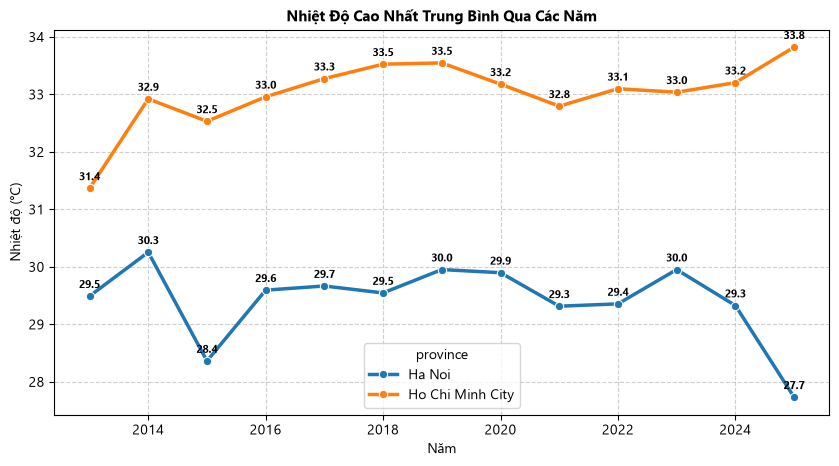

In [92]:
df_yearly = df[df['province'].isin(provinces_trend)] \
             .groupby(['Year', 'province'])['max'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_yearly, x='Year', y='max', hue='province', marker='o', linewidth=2.5, ax=ax)

# Ghi chú số liệu
for p in df_yearly['province'].unique():
    sub = df_yearly[df_yearly['province'] == p]
    for x, y in zip(sub['Year'], sub['max']):
        ax.text(x, y + 0.1, f"{y:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title("Nhiệt Độ Cao Nhất Trung Bình Qua Các Năm", fontsize=11, fontweight='bold')
ax.set_xlabel("Năm")
ax.set_ylabel("Nhiệt độ (°C)")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

##  Biểu đồ 2 – Chu kỳ lượng mưa theo tháng năm 2024

C:\Users\DELL\AppData\Local\Temp\ipykernel_14716\3773729649.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"Tháng {i}" for i in range(1,13)], rotation=15, ha='right')


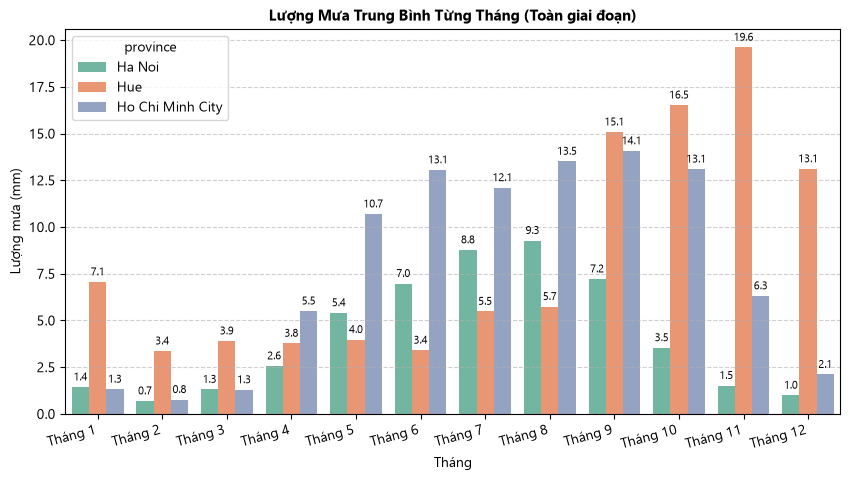

In [93]:
df_raw = df[df['province'].isin(provinces_monthly)]
df_monthly = df_raw.groupby(['Month', 'province'])['rain'].mean().reset_index()

# Tạo bảng đủ 12 tháng
full_months = pd.MultiIndex.from_product([range(1,13), provinces_monthly], names=['Month','province']).to_frame(index=False)
df_monthly = full_months.merge(df_monthly, on=['Month','province'], how='left').fillna(0)

# Tạo nhãn tháng
df_monthly['Month_Str'] = "Tháng " + df_monthly['Month'].astype(str)
df_monthly['Month_Str'] = pd.Categorical(df_monthly['Month_Str'], categories=[f"Tháng {i}" for i in range(1,13)], ordered=True)
df_monthly = df_monthly.sort_values('Month_Str')

# Vẽ
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_monthly, x='Month_Str', y='rain', hue='province', palette='Set2', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8)

ax.set_title("Lượng Mưa Trung Bình Từng Tháng (Toàn giai đoạn)", fontsize=11, fontweight='bold')
ax.set_xlabel("Tháng")
ax.set_ylabel("Lượng mưa (mm)")
ax.set_xticklabels([f"Tháng {i}" for i in range(1,13)], rotation=15, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Biểu đồ 3 – Boxplot biên độ nhiệt ngày đêm

C:\Users\DELL\AppData\Local\Temp\ipykernel_14716\2389650217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='province', y='Temp_Range', palette='Set2', width=0.4, ax=ax)
C:\Users\DELL\AppData\Local\Temp\ipykernel_14716\2389650217.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')


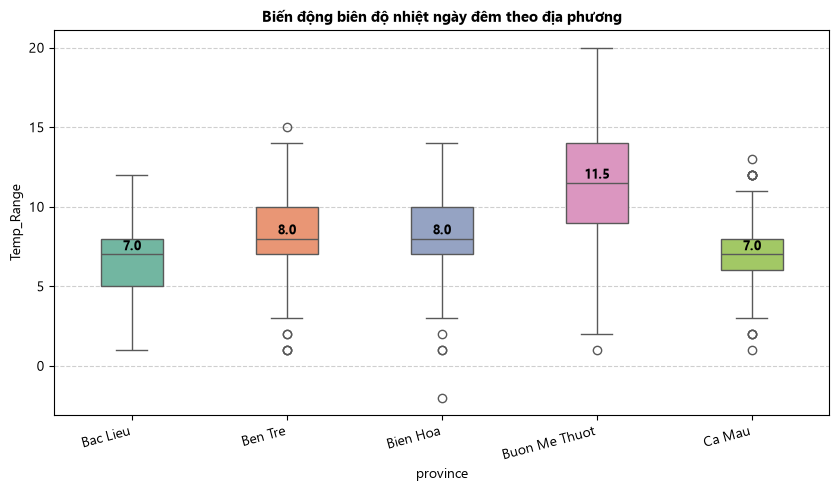

In [94]:
df_box = df[(df['province'].isin(provinces_boxplot)) & (df['Year'] == selected_year)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_box, x='province', y='Temp_Range', palette='Set2', width=0.4, ax=ax)

# Ghi giá trị median
for i, cat in enumerate(ax.get_xticks()):
    med = df_box[df_box['province'] == provinces_boxplot[i]]['Temp_Range'].median()
    if not np.isnan(med):
        ax.text(i, med + 0.1, f"{med:.1f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Biến động biên độ nhiệt ngày đêm theo địa phương", fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Biểu đồ 4 – Xếp hạng nhiệt độ trung bình năm cao nhất

C:\Users\DELL\AppData\Local\Temp\ipykernel_14716\757811283.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rank, x='province', y='avg_temp', palette='Reds_r', ax=ax)
C:\Users\DELL\AppData\Local\Temp\ipykernel_14716\757811283.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


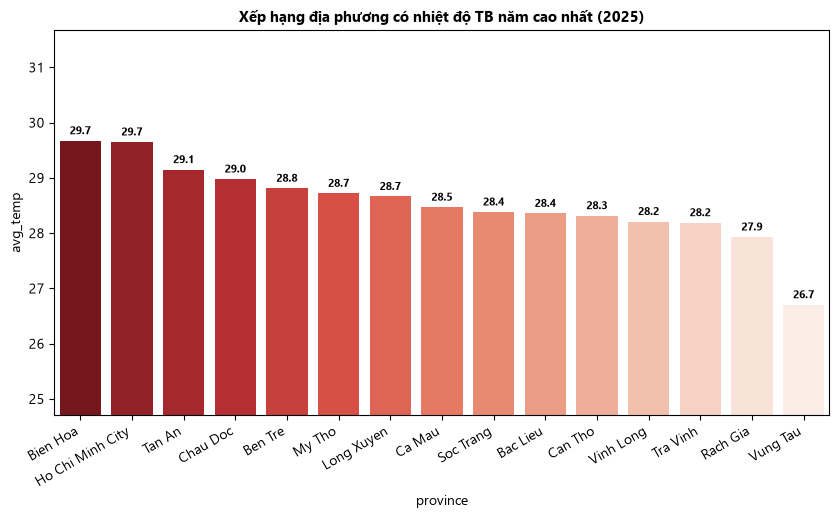

In [95]:
df_rank = df[df['Year'] == selected_year].groupby('province')['avg_temp'].mean().sort_values(ascending=False).reset_index().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_rank, x='province', y='avg_temp', palette='Reds_r', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8, fontweight='bold')

ax.set_title(f"Xếp hạng địa phương có nhiệt độ TB năm cao nhất ({selected_year})", fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylim(df_rank['avg_temp'].min() - 2, df_rank['avg_temp'].max() + 2)
plt.show()

## Biểu đồ 5 – Ma trận tương quan các chỉ số khí tượng vĩ mô

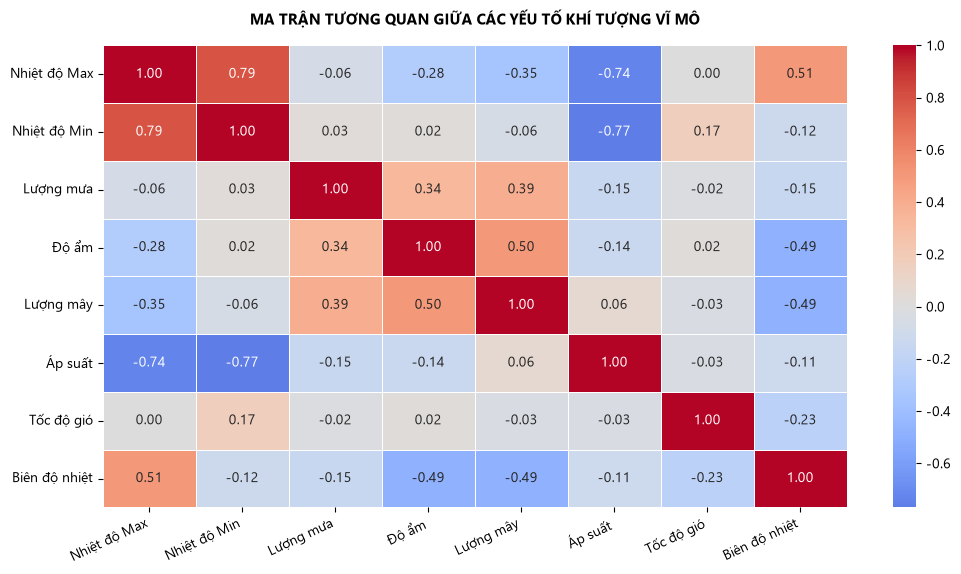

In [96]:
# Lấy các cột cần thiết và đặt tên tiếng Việt
cols = ['max','min','rain','humidi','cloud','pressure','wind','Temp_Range']
df_corr = df[df['Year'] == selected_year][cols].rename(columns={
    'max':'Nhiệt độ Max', 'min':'Nhiệt độ Min', 'rain':'Lượng mưa',
    'humidi':'Độ ẩm', 'cloud':'Lượng mây', 'pressure':'Áp suất',
    'wind':'Tốc độ gió', 'Temp_Range':'Biên độ nhiệt'
})

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=.5, ax=ax)

ax.set_title("MA TRẬN TƯƠNG QUAN GIỮA CÁC YẾU TỐ KHÍ TƯỢNG VĨ MÔ", fontsize=11, fontweight='bold', pad=15)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.show()

##  Biểu đồ 7 – Mô hình phân tích nhân quả biến trình khí hậu 3 tầng

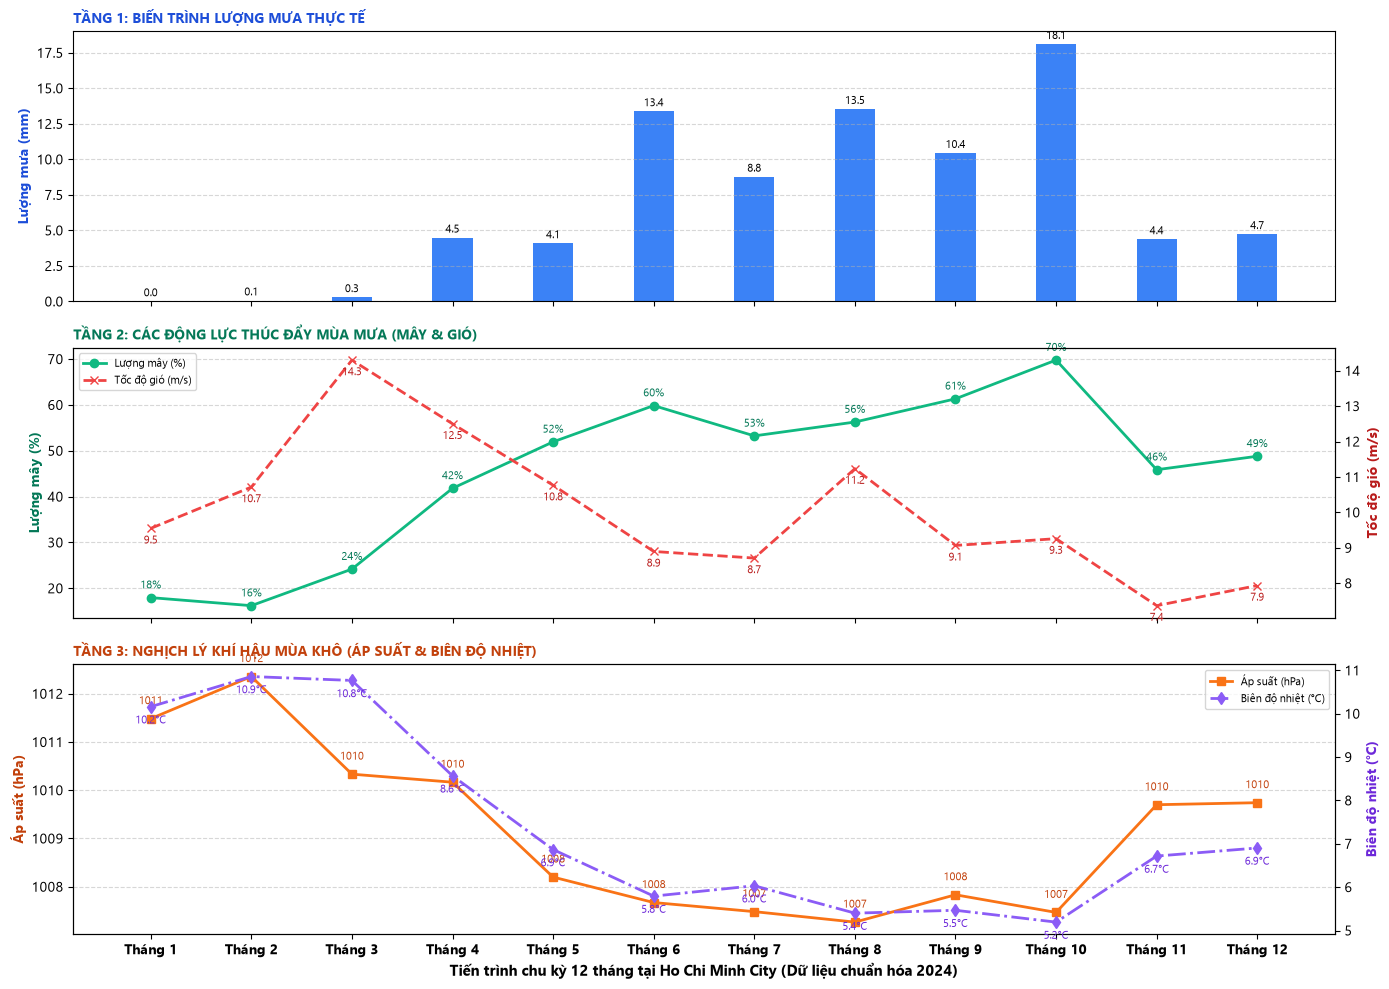

In [97]:
# Dữ liệu chuẩn hóa cho năm 2024 (đủ 12 tháng)
df_cause = df[(df['province'] == selected_cause_province) & (df['Year'] == 2024)]
df_season = df_cause.groupby('Month')[['rain','cloud','wind','pressure','Temp_Range']].mean().reindex(range(1,13), fill_value=0).reset_index()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Tầng 1: Lượng mưa
ax1.bar(df_season['Month'], df_season['rain'], width=0.4, color='#3B82F6')
ax1.set_ylabel("Lượng mưa (mm)", color='#1D4ED8', fontweight='bold')
ax1.bar_label(ax1.containers[0], fmt='%.1f', padding=2, fontsize=8)
ax1.set_title("TẦNG 1: BIẾN TRÌNH LƯỢNG MƯA THỰC TẾ", fontsize=10, fontweight='bold', loc='left', color='#1D4ED8')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Tầng 2: Mây & Gió (trục kép)
ax2.plot(df_season['Month'], df_season['cloud'], color='#10B981', marker='o', linewidth=2, label='Lượng mây (%)')
ax2.set_ylabel("Lượng mây (%)", color='#047857', fontweight='bold')
for x, y in zip(df_season['Month'], df_season['cloud']):
    if y>0: ax2.text(x, y+2, f"{y:.0f}%", color='#047857', fontsize=8, ha='center')

ax2_twin = ax2.twinx()
ax2_twin.plot(df_season['Month'], df_season['wind'], color='#EF4444', marker='x', linestyle='--', linewidth=2, label='Tốc độ gió (m/s)')
ax2_twin.set_ylabel("Tốc độ gió (m/s)", color='#B91C1C', fontweight='bold')
for x, y in zip(df_season['Month'], df_season['wind']):
    if y>0: ax2_twin.text(x, y-0.2, f"{y:.1f}", color='#B91C1C', fontsize=8, ha='center', va='top')

ax2.set_title("TẦNG 2: CÁC ĐỘNG LỰC THÚC ĐẨY MÙA MƯA (MÂY & GIÓ)", fontsize=10, fontweight='bold', loc='left', color='#047857')
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2_twin.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=8)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Tầng 3: Áp suất & Biên độ nhiệt (trục kép)
ax3.plot(df_season['Month'], df_season['pressure'], color='#F97316', marker='s', linewidth=2, label='Áp suất (hPa)')
ax3.set_ylabel("Áp suất (hPa)", color='#C2410C', fontweight='bold')
for x, y in zip(df_season['Month'], df_season['pressure']):
    if y>0: ax3.text(x, y+0.3, f"{y:.0f}", color='#C2410C', fontsize=8, ha='center')

ax3_twin = ax3.twinx()
ax3_twin.plot(df_season['Month'], df_season['Temp_Range'], color='#8B5CF6', marker='d', linestyle='-.', linewidth=2, label='Biên độ nhiệt (°C)')
ax3_twin.set_ylabel("Biên độ nhiệt (°C)", color='#6D28D9', fontweight='bold')
for x, y in zip(df_season['Month'], df_season['Temp_Range']):
    if y>0: ax3_twin.text(x, y-0.2, f"{y:.1f}°C", color='#6D28D9', fontsize=8, ha='center', va='top')

ax3.set_title("TẦNG 3: NGHỊCH LÝ KHÍ HẬU MÙA KHÔ (ÁP SUẤT & BIÊN ĐỘ NHIỆT)", fontsize=10, fontweight='bold', loc='left', color='#C2410C')
lines3, labels3 = ax3.get_legend_handles_labels()
lines3_twin, labels3_twin = ax3_twin.get_legend_handles_labels()
ax3_twin.legend(lines3 + lines3_twin, labels3 + labels3_twin, loc='upper right', fontsize=8)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

ax3.set_xticks(range(1,13))
ax3.set_xticklabels([f"Tháng {i}" for i in range(1,13)], fontweight='bold')
ax3.set_xlabel(f"Tiến trình chu kỳ 12 tháng tại {selected_cause_province} (Dữ liệu chuẩn hóa 2024)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Biểu đồ 8 – Lịch phân bổ Ngày Vàng khí hậu du lịch lý tưởng (Tab 3)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14716\222929532.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_monthly_comfort, x='Month', y='is_comfort_day', palette='YlOrRd', ax=ax)


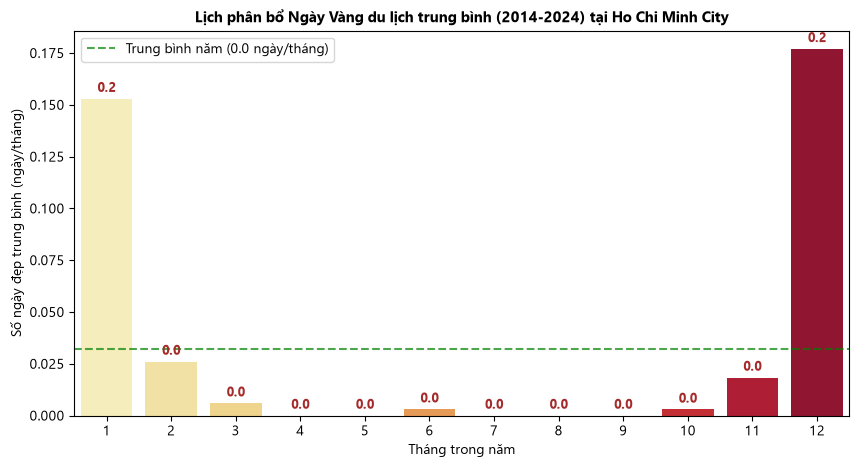

In [98]:
# Lọc giai đoạn 2014-2024
df_tour = df[(df['province'] == single_tour_province) & (df['Year'].between(start_year, end_year))]
df_monthly_comfort = df_tour.groupby('Month')['is_comfort_day'].mean().reindex(range(1,13), fill_value=0).reset_index()
baseline = df_monthly_comfort['is_comfort_day'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_monthly_comfort, x='Month', y='is_comfort_day', palette='YlOrRd', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9, fontweight='bold', color='brown')

ax.axhline(baseline, color='green', linestyle='--', alpha=0.7, label=f'Trung bình năm ({baseline:.1f} ngày/tháng)')
ax.set_title(f"Lịch phân bổ Ngày Vàng du lịch trung bình ({start_year}-{end_year}) tại {single_tour_province}", fontsize=11, fontweight='bold')
ax.set_xlabel("Tháng trong năm")
ax.set_ylabel("Số ngày đẹp trung bình (ngày/tháng)")
ax.legend()
plt.show()

## Xem trước Biểu đồ 8 — Số ngày cảnh báo rủi ro thời tiết cực đoan (Tab 3)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14716\222929532.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_monthly_comfort, x='Month', y='is_comfort_day', palette='YlOrRd', ax=ax)


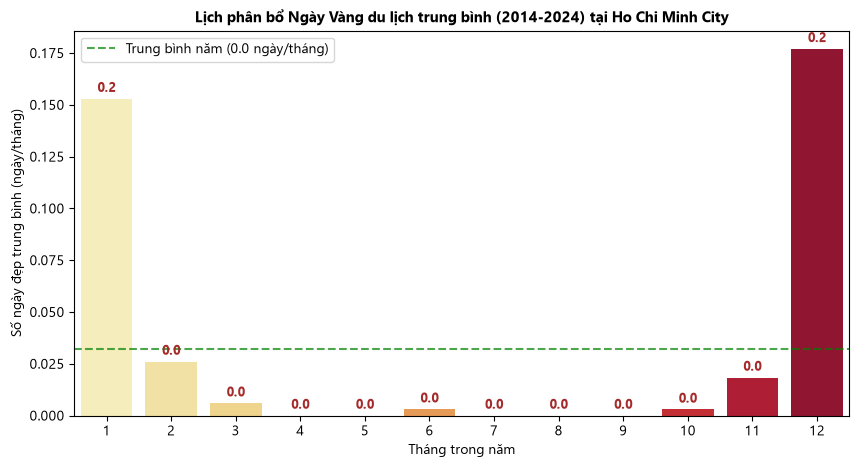

In [99]:
# Lọc giai đoạn 2014-2024
df_tour = df[(df['province'] == single_tour_province) & (df['Year'].between(start_year, end_year))]
df_monthly_comfort = df_tour.groupby('Month')['is_comfort_day'].mean().reindex(range(1,13), fill_value=0).reset_index()
baseline = df_monthly_comfort['is_comfort_day'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_monthly_comfort, x='Month', y='is_comfort_day', palette='YlOrRd', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9, fontweight='bold', color='brown')

ax.axhline(baseline, color='green', linestyle='--', alpha=0.7, label=f'Trung bình năm ({baseline:.1f} ngày/tháng)')
ax.set_title(f"Lịch phân bổ Ngày Vàng du lịch trung bình ({start_year}-{end_year}) tại {single_tour_province}", fontsize=11, fontweight='bold')
ax.set_xlabel("Tháng trong năm")
ax.set_ylabel("Số ngày đẹp trung bình (ngày/tháng)")
ax.legend()
plt.show()

## Biến động tổng số Ngày Vàng Du lịch giai đoạn lịch sử (Tab 3)

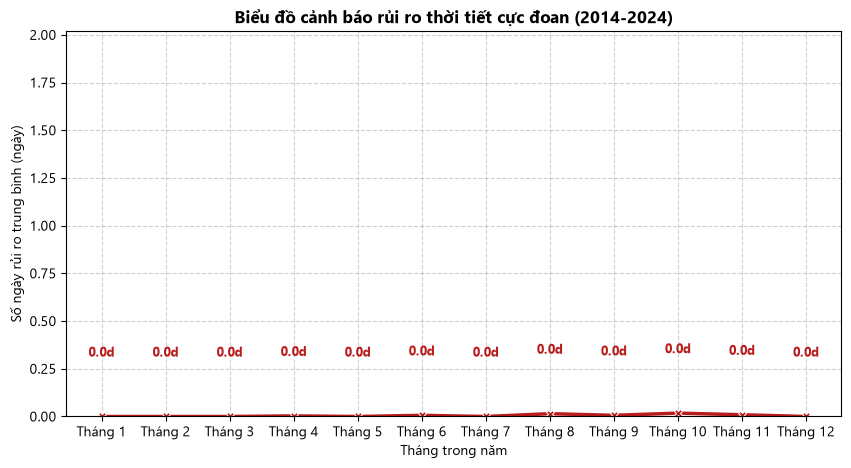

In [100]:
df_risk = df[(df['province'] == single_tour_province) & (df['Year'].between(start_year, end_year))]
df_risk_avg = df_risk.groupby('Month')['is_risk_day'].mean().reindex(range(1,13), fill_value=0).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_risk_avg, x='Month', y='is_risk_day', marker='X', color='#B91C1C', linewidth=2.5, ax=ax)

for x, y in zip(df_risk_avg['Month'], df_risk_avg['is_risk_day']):
    ax.text(x, y+0.3, f"{y:.1f}d", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#B91C1C')

ax.set_xticks(range(1,13))
ax.set_xticklabels([f"Tháng {i}" for i in range(1,13)])
ax.set_ylim(0, df_risk_avg['is_risk_day'].max() + 2)
ax.set_xlabel("Tháng trong năm")
ax.set_ylabel("Số ngày rủi ro trung bình (ngày)")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title(f"Biểu đồ cảnh báo rủi ro thời tiết cực đoan ({start_year}-{end_year})", fontweight='bold')
plt.show()

## Biểu đồ 10 – Xếp hạng tài nguyên ngày vàng toàn quốc (năm 2024)

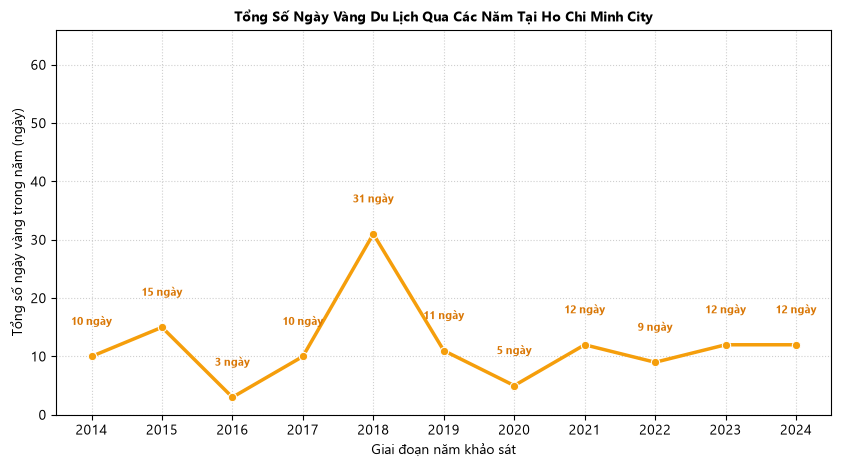

In [101]:
df_hist = df[(df['province'] == single_tour_province) & (df['Year'].between(start_year, end_year))]
df_yearly_comfort = df_hist.groupby('Year')['is_comfort_day'].sum().reindex(range(start_year, end_year+1), fill_value=0).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_yearly_comfort, x='Year', y='is_comfort_day', marker='o', color='#F59E0B', linewidth=2.5, ax=ax)

for x, y in zip(df_yearly_comfort['Year'], df_yearly_comfort['is_comfort_day']):
    ax.text(x, y+5, f"{int(y)} ngày", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#D97706')

ax.set_title(f"Tổng Số Ngày Vàng Du Lịch Qua Các Năm Tại {single_tour_province}", fontsize=10, fontweight='bold')
ax.set_xlabel("Giai đoạn năm khảo sát")
ax.set_ylabel("Tổng số ngày vàng trong năm (ngày)")
ax.set_xticks(range(start_year, end_year+1))
ax.set_ylim(0, df_yearly_comfort['is_comfort_day'].max() + 35)
ax.grid(axis='both', linestyle=':', alpha=0.6)
plt.show()